<a href="https://colab.research.google.com/github/draiscigianfranco/Classificazione-Automatica-Ticket-e-Priority/blob/main/PROJECT_WORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Work: Classificazione Automatica Ticket e Priorità
Autore: [Gianfranco Draisci]
Strumento: Jupyter Notebook (Anaconda Python 3.x)

In [ ]:
import random
import pandas as pd

random.seed(0)

# Definizione del dizionario con titles e bodies divisi per categoria
dizionario = {
    'Amministrazione': {
        'titles': [
            "Fattura non ricevuta",
            "Mancato accredito bonifico",
            "Sollecito pagamento",
            "Errore importo fattura",
            "Richiesta nota di credito",
            "Doppio addebito carta",
            "Copia ricevuta fiscale",
            "Dettagli iban per versamento",
            "Coordinate bancarie errate",
            "Storno addebito non dovuto"
        ],
        'bodies': [
            "Buongiorno, ho effettuato il pagamento la settimana scorsa ma la fattura non risulta ancora emessa. Potrebbe verificare? Cordiali saluti",
            "Spett.le Amministrazione, risulta un addebito duplicato sul mio conto corrente relativo all'ultimo ordine. attendo un vostro riscontro.",
            "Gentile supporto, chiedo gentilmente l'emissione di una nota di credito per l'importo errato presente nell'ultima nota contabile. Grazie.",
            "Buongiorno, non riesco a scaricare la fattura elettronica dal portale dedicato. Potreste inviarmi una copia via mail? Un cordiale saluto",
            "Salve, desidero verificare lo stato dell'accredito relativo al bonifico effettuato in data odierna. Resto in attesa di conferma.",
            "Spett.le reparto contabilità, L'importo fatturato non corrisponde a quanto concordato nel contratto iniziale. Cordiali saluti.",
            "Buongiorno, vi chiedo di inviarmi le coordinate IBAN aggiornate per completare il versamento del saldo. Grazie e buona giornata.",
            "Gentili signori, vi segnalo che la ricevuta fiscale allegata all'ultimo ordine presenta dati errati. Vi chiedo di rinviarla corretta.",
            "Buongiorno, vi scrivo per sollecitare la verifica di un pagamento inviato 5 giorni fa ma ancora segnalato come in sospeso.",
            "Salve, vi chiedo di procedere con lo storno dell'addebito non dovuto presente nell'estratto conto del mese scorso. Cordiali saluti."
        ]
    },
    'Tecnico': {
        'titles': [
            "Errore login portale",
            "Server unreachable offline",
            "Schermata blu sistema",
            "Bug esportazione PDF",
            "Password dimenticata e reset",
            "Malfunzionamento app mobile",
            "Blocco totale database",
            "Lentezza caricamento dashboard",
            "Errore 500 server",
            "Problema connessione API"
        ],
        'bodies': [
            "Spett.le assistenza tecnica, è impossibile accedere all'account utente in quanto viene continuamente segnalata password errata.",
            "Gentile supporto, vi segnalo un bug critico che blocca il flusso di lavoro operativo degli utenti. Distinti saluti",
            "Salve, dopo l'ultimo aggiornamento la schermata di sistema mostra un errore critico blu all'avvio. Richiedo assistenza.",
            "Salve, segnalo che l'applicazione crasha sistematicamente durante la fase di esportazione dei report aziendali. Cordiali saluti.",
            "Gentili tecnici, vi chiedo di procedere con il reset manuale della password di sistema per l'utente amministratore. Grazie.",
            "Buongiorno, l'applicazione mobile continua a chiudersi da sola ogni volta che tento di effettuare l'accesso. Resto in attesa.",
            "Urgente: il server del database principale è in blocco totale da questa mattina. Richiesto intervento immediato.",
            "Buongiorno, la dashboard di monitoraggio presenta un'estrema lentezza nel caricamento dei dati. Potete verificare lo stato dei server?",
            "Buongiorno, da questa mattina il sistema restituisce errore 500 e impedisce qualsiasi operazione agli utenti. Attendo aggiornamenti urgenti.",
            "Spett.le team, le API di integrazione restituiscono errore di connessione e non sincronizzano i dati. Cordiali saluti."
        ]
    },
    'Commerciale': {
        'titles': [
            "Richiesta preventivo aziendale",
            "Informazioni abbonamento premium",
            "Demo prodotto software",
            "Sconto rinnovo annuale",
            "Upgrade licenze utenti",
            "Listino prezzi aggiornato",
            "Informazioni offerte commerciali",
            "Personalizzazione pacchetto enterprise",
            "Chiarimenti contratto",
            "Nuova attivazione servizio"
        ],
        'bodies': [
            "Buongiorno, vorremmo ricevere un preventivo dettagliato per l'acquisto di 50 nuove licenze aziendali. Cordiali saluti.",
            "Buongiorno, vi chiedo l'invio della documentazione completa relativa ai piani di abbonamento premium attualmente disponibili.",
            "Spett.le reparto commerciale, siamo interessati a prenotare una demo del vostro software per il nostro team. In attesa di un vostro riscontro.",
            "Gentili colleghi, desideriamo conoscere le condizioni e gli eventuali sconti previsti per il rinnovo annuale dell'abbonamento.",
            "Buongiorno, richiedo cortesemente l'invio del listino prezzi aggiornato per i moduli aggiuntivi dell'offerta aziendale.",
            "Salve, vorrei sapere se sono previste promozioni o pacchetti speciali per startup in caso di attivazione entro fine mese. Grazie.",
            "Salve, vorrei ricevere informazioni commerciali sui costi e le modalità per effettuare l'upgrade al piano enterprise. Grazie in anticipo.",
            "Spett.le servizio clienti, chiediamo un contatto telefonico per valutare una personalizzazione su misura del pacchetto da voi offerto.",
            "Gentile commerciale, vi chiedo maggiori chiarimenti in merito ad alcune clausole presenti nella proposta di contratto inviata.",
            "Buongiorno, saremmo interessati a conoscere le caratteristiche e i costi previsti per l'attivazione di un nuovo servizio professionale."
        ]
    }
}

# Parole chiave per l'assegnazione della priorità
parole_alta_priorita = {"blocco totale", "errore 500", "schermata blu", "server unreachable", "crash database", "bug critico", "impossibile accedere",
                        "intervento immediato", "chiudersi da sola", "errore critico", "blocca il flusso", "addebito duplicato", "addebito non dovuto",
                        "non corrisponde", "dati errati"}
parole_media_priorita = { "reset manuale", "lentezza caricamento", "non sincronizzano", "esportazione dei report", "sollecito",
                          "non risulta emessa", "in sospeso", "nota di credito", "mancato accredito", "errore importo", "upgrade licenze",
                          "errore di connessione", "preventivo dettagliato", "chiarimenti contratto", "pacchetto enterprise"}

# Creazione dataset sintetico da 300 ticket testuali
data = []
categories = ['Amministrazione', 'Tecnico', 'Commerciale']

for i in range(1, 301):
  category = random.choice(categories)
  title = random.choice(dizionario[category]['titles'])
  body = random.choice(dizionario[category]['bodies'])

  full_text = f"{title} {body}".lower()

  if any( k in full_text for k in parole_alta_priorita ): priority = "alta"
  elif any( k in full_text for k in parole_media_priorita ): priority = "media"
  else:
    priority = "bassa"

  data.append({"id": f"TICKET-{i}", "title": title, "body": body, "category": category, "priority": priority,})

df = pd.DataFrame(data)

# Esportazione in CSV
df.to_csv("tickets_dataset.csv", index=False)
print("Dataset di 300 ticket salvato in 'tickets_dataset.csv'")

Dataset di 300 ticket salvato in 'tickets_dataset.csv'


=========== RISULTATI VALUTAZIONE ===========
 Categoria -> Accuracy: 1.00 | F1 Macro: 1.00
 Priorità  -> Accuracy: 0.72 | F1 Macro: 0.67



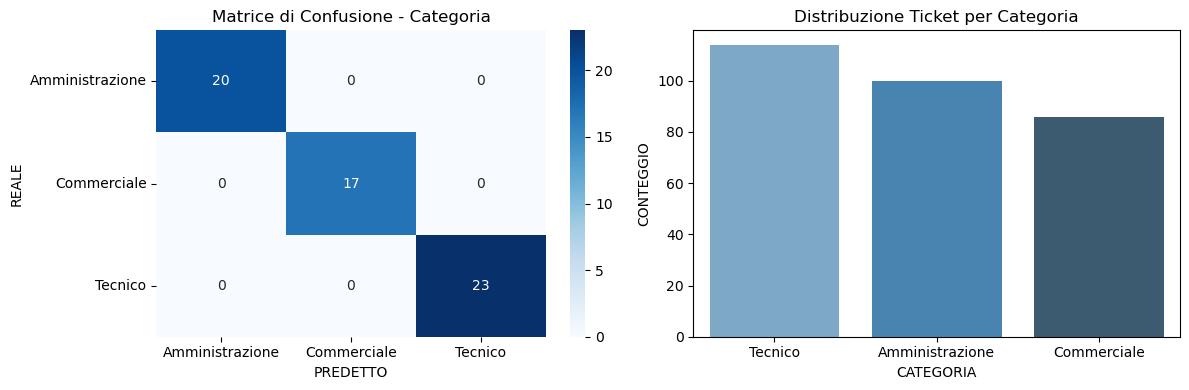


Esportazione di batch_predictions.csv effettuata


In [ ]:
import re
import string
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Caricamento e Preprocessing
df = pd.read_csv('tickets_dataset.csv')


def clean_text(text):
  text = str(text).lower()
  text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
  return re.sub(r'\s+', ' ', text).strip()


df['text_clean'] = (df['title'] + ' ' + df['body']).apply(clean_text)

X = df['text_clean']
y_category = df['category']
y_priority = df['priority']

# Split 80/20
X_train, X_test, y_category_train, y_category_test, y_priority_train, y_priority_test = (
    train_test_split(X, y_category, y_priority, test_size=0.2, random_state=0, stratify=y_category)
)

# Addestramento Pipeline categoria
pipe_category = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2))), ('clf', MultinomialNB())])
pipe_category.fit(X_train, y_category_train)

# Addestramento Pipeline priorità
pipe_priority = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2))), ('clf', MultinomialNB())])
pipe_priority.fit(X_train, y_priority_train)

# Valutazione
pred_category = pipe_category.predict(X_test)
pred_priority = pipe_priority.predict(X_test)

print("="*11 + " RISULTATI VALUTAZIONE " + "="*11)
print(f" Categoria -> Accuracy: {accuracy_score(y_category_test, pred_category):.2f} | F1 Macro: {f1_score(y_category_test, pred_category, average='macro'):.2f}")
print(f" Priorità  -> Accuracy: {accuracy_score(y_priority_test, pred_priority):.2f} | F1 Macro: {f1_score(y_priority_test, pred_priority, average='macro'):.2f}\n")

# Generazione Matrice di Confusione
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels_category = sorted(y_category.unique())
cm = confusion_matrix(y_category_test, pred_category, labels=labels_category)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_category, yticklabels=labels_category, ax=axes[0])
axes[0].set_title('Matrice di Confusione - Categoria')
axes[0].set_xlabel('PREDETTO')
axes[0].set_ylabel('REALE')

# Generazione grafico di distribuzione
df_counts = df['category'].value_counts().reset_index()
df_counts.columns = ['CATEGORIA', 'CONTEGGIO']
sns.barplot(data=df_counts, x='CATEGORIA', y='CONTEGGIO', hue='CATEGORIA', palette='Blues_d', legend=False, ax=axes[1])
axes[1].set_title('Distribuzione Ticket per Categoria')
plt.tight_layout()
plt.show()

# Esportazione CSV Batch
df_batch = df.iloc[X_test.index].copy()
df_batch['pred_category'] = pred_category
df_batch['pred_priority'] = pred_priority
df_batch[['id', 'title', 'body', 'category', 'priority', 'pred_category', 'pred_priority']].to_csv('batch_predictions.csv', index=False)
print ("\nEsportazione di batch_predictions.csv effettuata")

In [ ]:
# Funzione "Dashboard" da eseguire direttamente nel Notebook
def classifica_ticket_interattivo(titolo, descrizione):
  testo_raw = f'{titolo} {descrizione}'
  testo_clean = clean_text(testo_raw)

  # Previsioni
  category_pred = pipe_category.predict([testo_clean])[0]
  priority_pred = pipe_priority.predict([testo_clean])[0]

  # Estrazione dei 5 token con peso TF-IDF maggiormente rilevante
  tfidf_vec = pipe_category.named_steps['tfidf']
  v_input = tfidf_vec.transform([testo_clean])
  feature_names = tfidf_vec.get_feature_names_out()

  cx = v_input.tocoo()
  weights = sorted(zip(cx.col, cx.data), key=lambda x: x[1], reverse=True)[:5]
  top_tokens = [feature_names[i] for i, _ in weights]

  print("=" *90)
  print(f"TICKET: {titolo}")
  print(f"CATEGORIA PREVISTA: {category_pred.upper()}")
  print(f"PRIORITÀ SUGGERITA: {priority_pred.upper()}")
  print(f"5 PAROLE PIÙ INFLUENTI: {', '.join(top_tokens)}")
  print("=" * 90 + "\n")


# Esempi di test immediati
classifica_ticket_interattivo("Errore 500 server offline", "Il database principale è bloccato e nessun utente riesce ad accedere.")
classifica_ticket_interattivo("Sollecito invio fattura", "Buon giorno. Richiedo l'invio della fattura con annessa nota di credito.")
classifica_ticket_interattivo("Preventivo rinnovo licenze", "Desideriamo conoscere le offerte per l'upgrade del nostro piano aziendale.")

TICKET: Errore 500 server offline
CATEGORIA PREVISTA: TECNICO
PRIORITÀ SUGGERITA: ALTA
5 PAROLE PIÙ INFLUENTI: 500 server, database principale, principale, accedere, ad

TICKET: Sollecito invio fattura
CATEGORIA PREVISTA: AMMINISTRAZIONE
PRIORITÀ SUGGERITA: MEDIA
5 PAROLE PIÙ INFLUENTI: invio, fattura, sollecito, invio della, richiedo

TICKET: Preventivo rinnovo licenze
CATEGORIA PREVISTA: COMMERCIALE
PRIORITÀ SUGGERITA: BASSA
5 PAROLE PIÙ INFLUENTI: desideriamo, desideriamo conoscere, piano, nostro, offerte

